# Refuting Causal Estimates

- This notebook teaches the philosophy and methods of refutation-based
  validation for causal inference
  - Why we cannot prove causality from observational data alone
  - How to systematically challenge causal claims using refutation tests
  - How to interpret refutation results and decide what to trust
  - How to compare competing estimation methods using robustness batteries

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

In [2]:
# Helpers imports.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

# Notebook-specific utilities.
import dowhy_04_refuting_estimates_utils as darti

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)
darti.init_loggers(_LOG)

_LOG.info("Notebook initialized")

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-fb9fe491-882f-4da8-8be6-cc7096573778.json'
INFO  Notebook initialized


# Cell 1: Why We Cannot Prove Causality

**Goal**: Build intuition about fundamental limitations of causal inference

**Key Concepts**:
- Observational data cannot distinguish between causal and confounded
  relationships
- Many different causal structures produce identical statistical patterns
  (observational equivalence)
- No amount of data can rule out hidden confounders
- Karl Popper's falsification philosophy: we cannot prove causality, but we
  can try to refute it

**Key Insight**: Confidence in a causal claim comes from surviving many
systematic challenges, not from statistical proof.

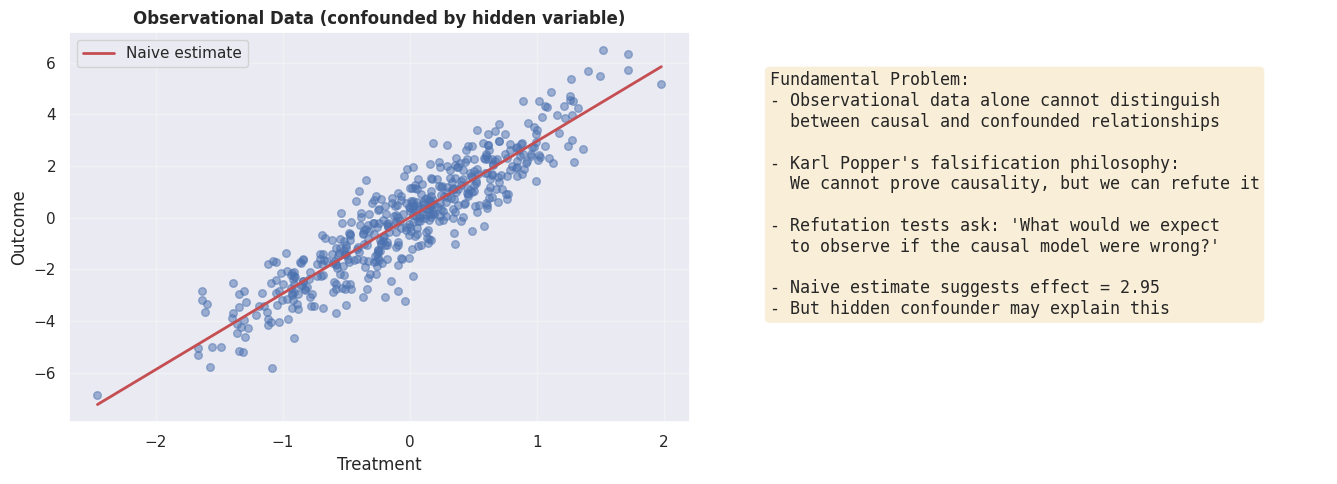

In [3]:
# Visualize the fundamental problem: why we cannot prove causality.
darti.cell1_plot_why_we_cannot_prove_causality()

# Cell 2: Introduction to Refutation Methods

**Goal**: Survey the landscape of refutation approaches

**Two Categories of Refutations**:
- **Negative control refutations**: Test necessary conditions that good
  estimators must satisfy
  - Placebo treatment: good estimators find zero effect for fake treatments
  - Dummy outcome: estimators should not find spurious effects
  - Random confounder: estimates should be stable when adding noise
  - Data subsample: effects should be consistent across subsets
- **Sensitivity analysis**: Test robustness when key assumptions are relaxed
  - Simulation-based: directly perturb data to simulate confounding
  - Partial R² based: use observed variance to bound hidden confounders

**Key Principle**: If an estimator fails any test (p-value < 0.05), it
indicates methodological problems.

In [4]:
# Display a table of refutation methods and interpretation guidance.
darti.cell2_show_refutation_methods_table()

,Method,What It Tests,Pass Criterion,When to Use
0,Placebo Treatment,Spurious effect detection,Placebo effect ≈ 0,Check for spurious effects
1,Dummy Outcome,Systematic bias,Dummy effect ≈ 0,Detect systematic bias
2,Random Confounder,Robustness to irrelevant covariates,Estimate stable,Test robustness
3,Data Subsample,Consistency across subsamples,Low variance across subsamples,Real data with temporal/subgroup variation
4,Sensitivity (Simulation),Robustness to hidden confounding,Effect robust to confounding,When assumptions may be violated
5,Sensitivity (Partial R²),Bounds under unobserved confounding,Bounds are informative,Econometric applications



Interpretation guide:
- PASS: Estimator passes the test (result is as expected)
- FAIL: Estimator fails the test (unexpected result at p < 0.05)
- Multiple passes: High confidence in the causal estimate


# Cell 3: Simple Synthetic Data with Known Truth

**Goal**: Establish a baseline where we know the true causal effect

**Data-Generating Process**:
- $Z \sim N(0, 1)$: Hidden confounder
- $X = 0.5Z + N(0, 1)$: Treatment (influenced by confounder)
- $Y = 2X + 0.8Z + N(0, 1)$: Outcome (causal effect = 2)

**Challenge**: We observe X and Y are correlated, but Z is hidden. Naive
estimation will be biased.

In [5]:
# Generate synthetic data with known ground truth.
df, true_ate = darti.cell3_generate_synthetic_data(
    n_samples=500,
    true_ate=2.0,
    confounder_strength=0.8,
    random_state=42,
)

_LOG.info(f"Generated {len(df)} samples with true ATE = {true_ate}")

INFO  Generated 500 samples with true ATE = 2.0


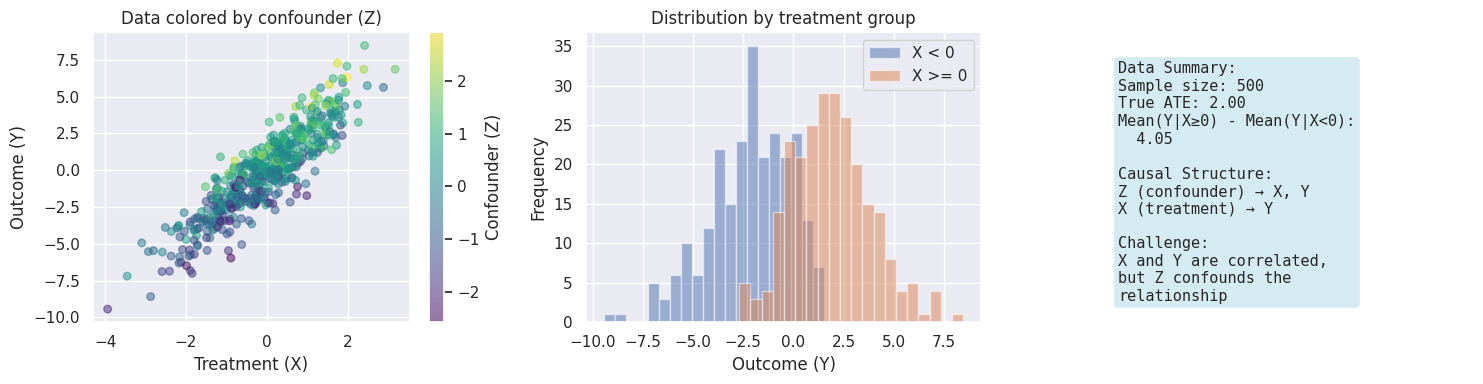

In [6]:
# Visualize the data-generating process.
darti.cell3_visualize_data(df, true_ate)

# Cell 4: Naive Estimation Reveals the Problem

**Goal**: Demonstrate that naive methods can give very wrong answers

**What We'll Do**:
- Estimate the treatment effect using naive linear regression (ignoring Z)
- Compare to ground truth to quantify bias
- Discuss why this happens: omitted variable bias

In [7]:
# Estimate causal effect using naive methods.
naive_results = darti.cell4_naive_estimation(df, true_ate)

_LOG.info(f"Naive estimate: {naive_results['estimate']:.3f}")
_LOG.info(f"True ATE: {naive_results['true_ate']:.3f}")
_LOG.info(f"Bias: {naive_results['bias']:.3f}")

INFO  Naive estimate: 2.277
INFO  True ATE: 2.000
INFO  Bias: 0.277


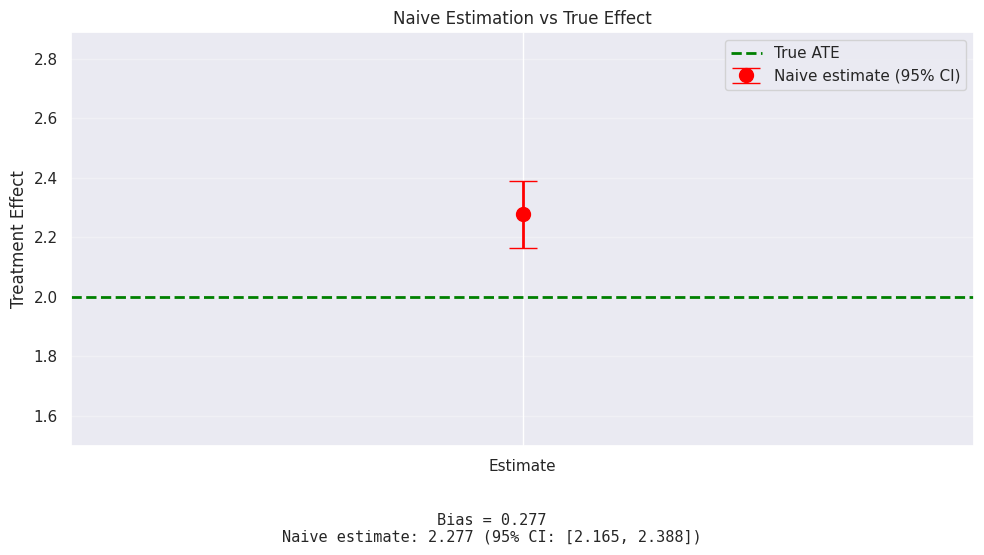

In [8]:
# Visualize the bias in naive estimation.
darti.cell4_visualize_bias(naive_results)

# Cell 5: Placebo Treatment Refutation

**Goal**: Learn how placebo treatment tests detect spurious effects

**Concept**: If we assign a fake treatment that cannot possibly have a causal
effect, a good estimator should find zero effect. A bad estimator finds
spurious effects.

**Interpretation**:
- **Pass**: Placebo effects distributed around zero, p-value > 0.05
- **Fail**: Placebo effects systematically non-zero, p-value < 0.05

In [9]:
# Run placebo treatment refutation.
placebo_results = darti.cell5_run_placebo_refutation(
    df,
    true_ate,
    n_placebos=50,
    random_state=42,
)

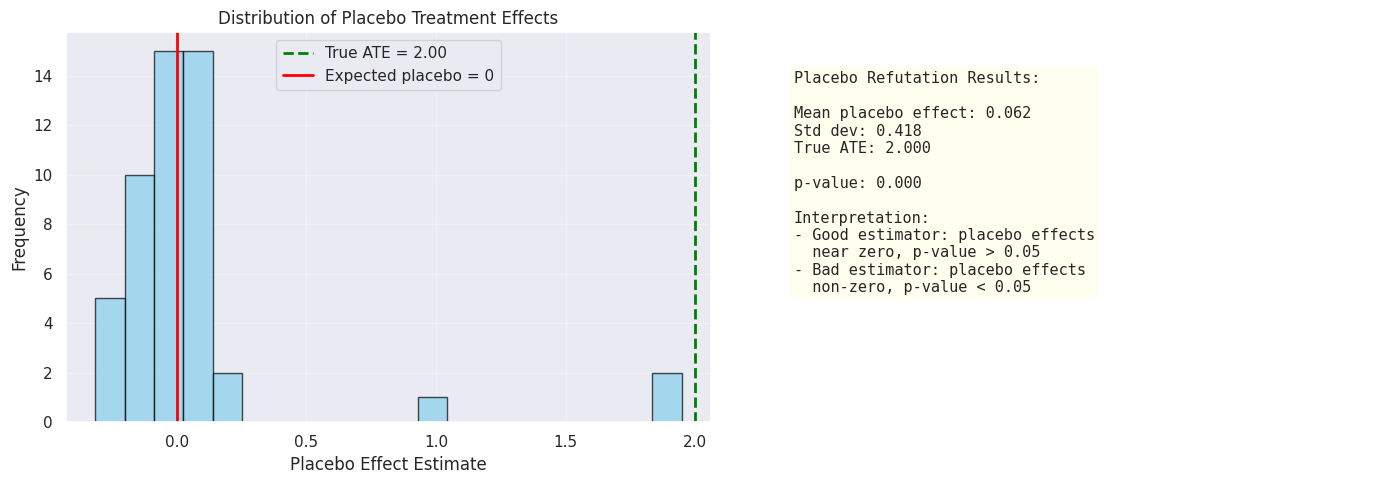

In [10]:
# Visualize the distribution of placebo effects.
darti.cell5_visualize_placebo(placebo_results)

# Cell 6: Dummy Outcome Refutation

**Goal**: Learn how dummy outcome tests reveal systematic bias

**Concept**: Create artificial outcome variables with no causal relationship
to treatment. A good estimator should find zero effect on all dummy outcomes.

**Interpretation**:
- **Pass**: True effect is extreme in the dummy distribution (good signal)
- **Fail**: True effect in the center of dummy distribution (spurious)

In [11]:
# Run dummy outcome refutation.
dummy_results = darti.cell6_run_dummy_outcome_refutation(
    df,
    true_ate,
    n_dummy=100,
    random_state=42,
)

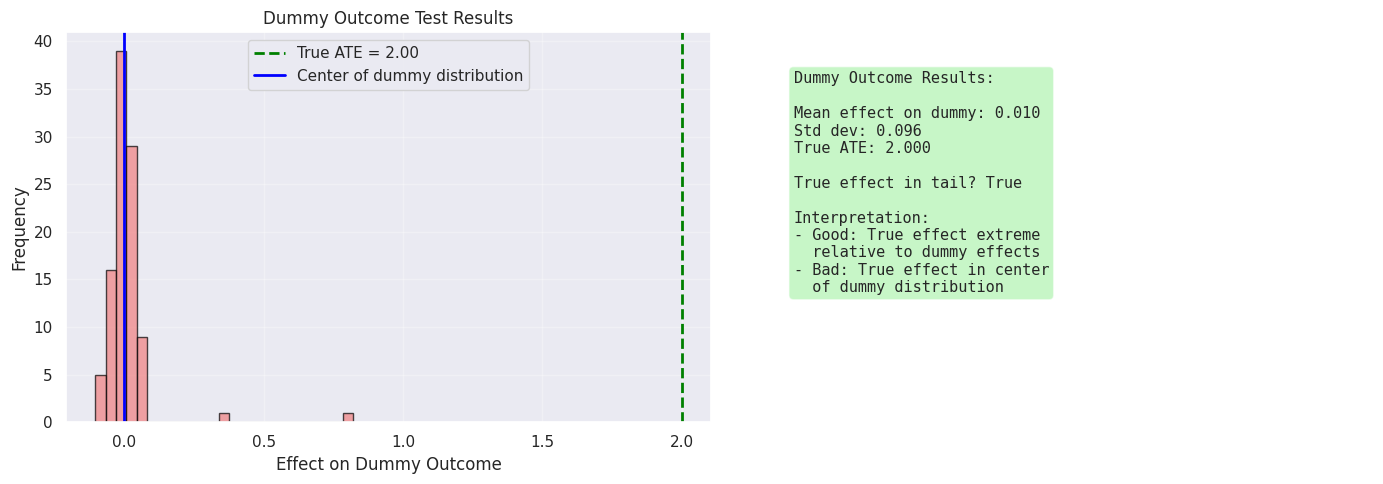

In [12]:
# Visualize the distribution of dummy outcome effects.
darti.cell6_visualize_dummy_outcome(dummy_results)

# Cell 7: Random Common Cause Refutation

**Goal**: Test whether estimator incorrectly adjusts for irrelevant
confounders

**Concept**: Introduce random variables as fake confounders. A good estimator
should not change estimates when we wrongly adjust for them.

**Interpretation**:
- **Pass**: Estimates stable despite random confounders (low std dev)
- **Fail**: Estimates vary widely with confounder choice (high std dev)

In [13]:
# Run random confounder refutation.
confounder_results = darti.cell7_run_random_confounder_refutation(
    df,
    n_confounders=10,
    random_state=42,
)

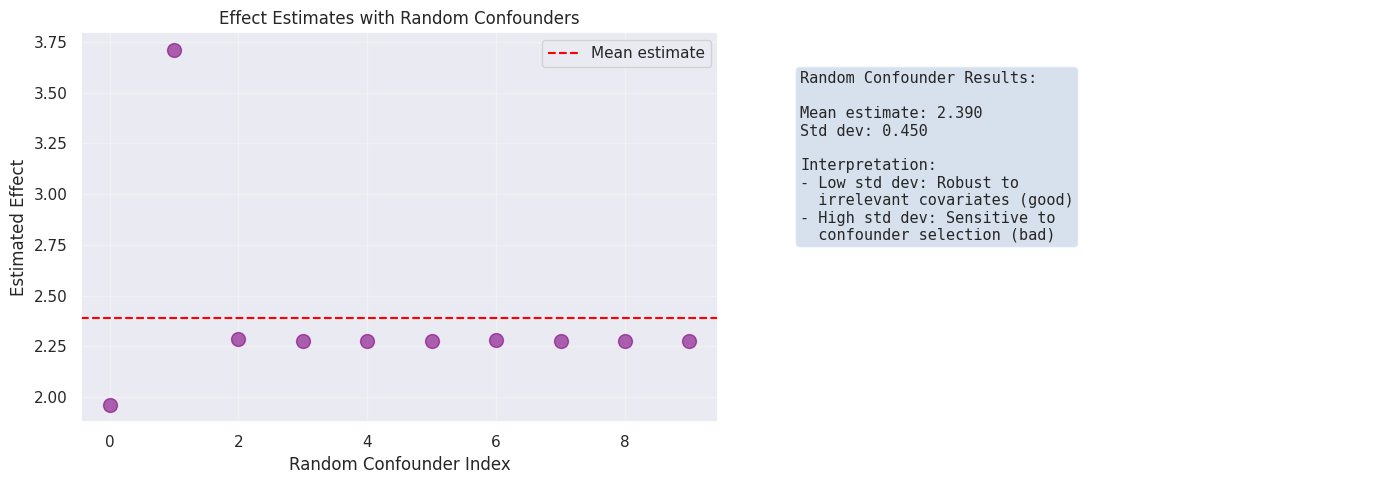

In [14]:
# Visualize sensitivity to random confounders.
darti.cell7_visualize_random_confounder(confounder_results)

# Cell 8: Data Subsample Refutation

**Goal**: Test consistency and stability of estimates across data subsets

**Concept**: If the causal relationship is real and estimation is robust,
the effect estimate should be consistent across random subsamples.

**Interpretation**:
- **Pass**: Subsample estimates concentrated with low variance (stable)
- **Fail**: Subsample estimates highly variable (unstable)

In [15]:
# Run subsample refutation.
subsample_results = darti.cell8_run_subsample_refutation(
    df,
    subsample_fraction=0.8,
    n_subsamples=50,
    random_state=42,
)

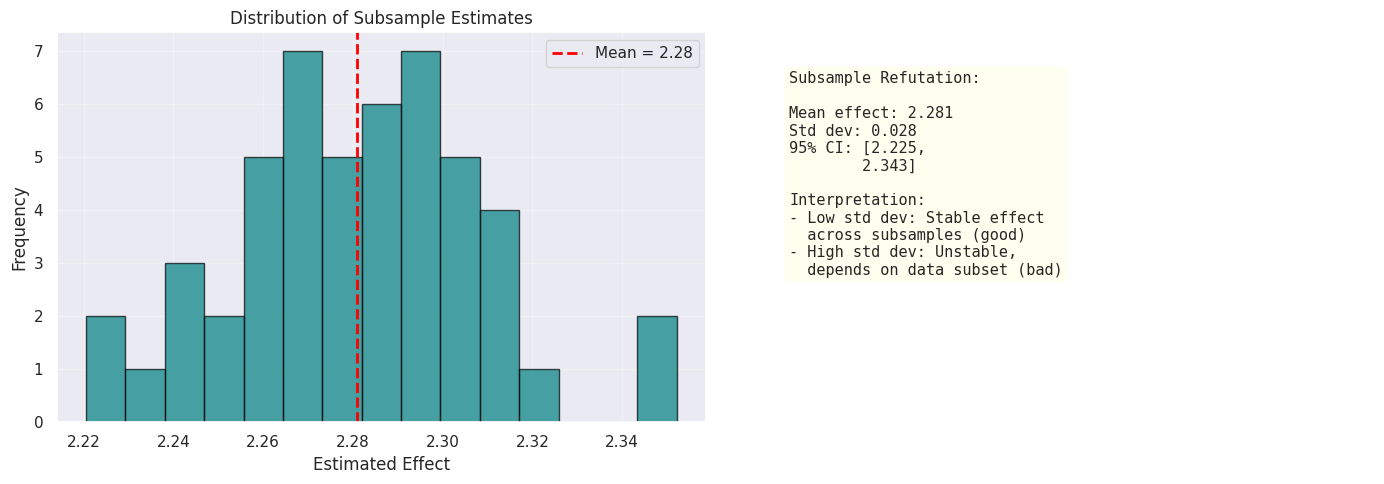

In [16]:
# Visualize consistency across subsamples.
darti.cell8_visualize_subsample(subsample_results)

# Cell 9: Sensitivity Analysis to Unobserved Confounding

**Goal**: Understand robustness when key assumptions are violated

**Core Concept**: We cannot observe hidden confounders, but we can test
robustness by assuming they exist and checking if conclusions hold.

**Three Approaches**:
- Simulation-based: directly add noise to simulate confounding
- Partial R² based: use observed variance to bound hidden confounder strength
- Reisz estimator based: derive bounds under unobserved confounding violations

**Key Question**: At what level of hidden confounding would conclusions
reverse?

In [17]:
# Run sensitivity analysis.
sensitivity_results = darti.cell9_sensitivity_analysis(
    df,
    confounder_strengths=[0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0],
    random_state=42,
)

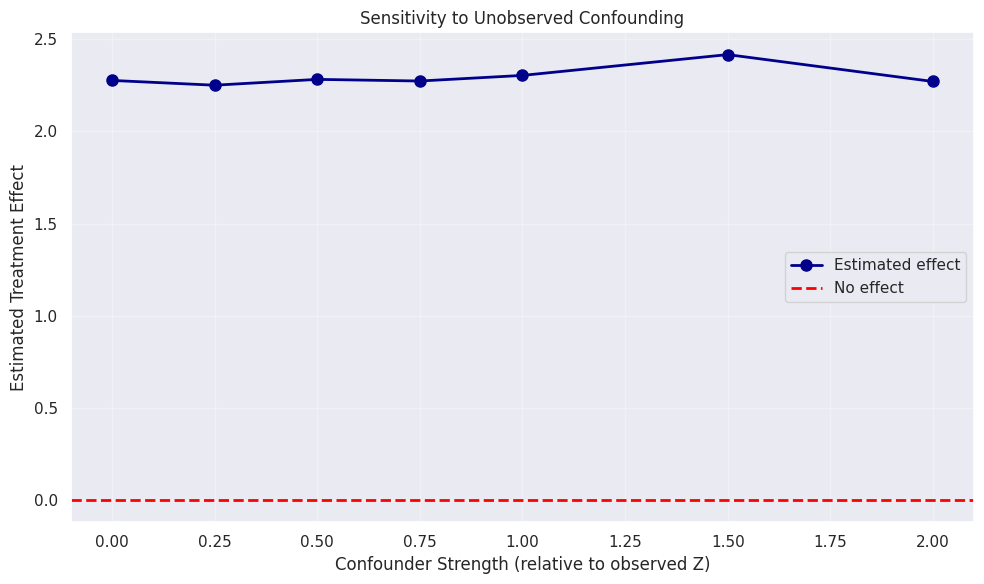

In [18]:
# Visualize sensitivity bounds.
darti.cell9_visualize_sensitivity(sensitivity_results)

# Cell 10: Comparing Multiple Estimators via Refutations

**Goal**: Use refutation tests to rank competing causal estimation methods

**Approach**:
- Apply all refutation methods to multiple estimators
- For each estimator, collect results from previous cells
- Create comparison scorecard: which estimators pass most tests?

**Interpretation**:
- Estimator passing all tests: most trustworthy
- Estimator failing tests: methodological issues

In [19]:
# Compare multiple estimation methods.
comparison_results = darti.cell10_compare_estimators(df)

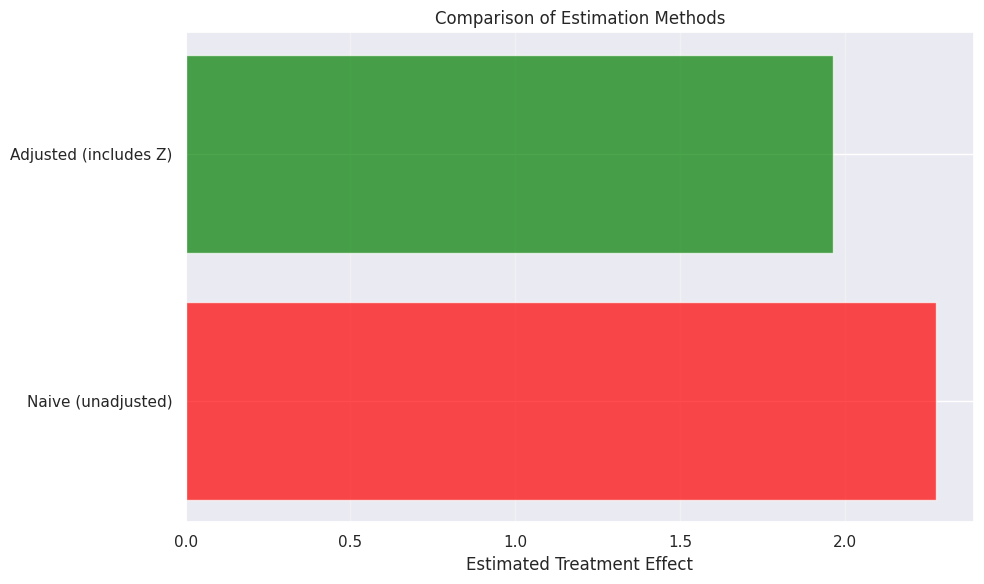

In [20]:
# Visualize comparison of estimators.
darti.cell10_visualize_comparison(comparison_results)

# Cell 11: Real Data Example: Job Training Impact

**Goal**: Apply complete refutation workflow to realistic problem with stakes

**Scenario**: Evaluate impact of job training program on earnings

**Data**: Individuals with varying training participation and post-training
earnings, with potential selection bias from unmeasured motivation.

**Question**: Does the training program actually increase earnings, or is the
observed effect due to selection bias?

In [21]:
# Create realistic job training dataset.
job_df = darti.cell11_create_job_training_data(
    n_samples=1000,
    random_state=42,
)

_LOG.info(f"Generated job training dataset with {len(job_df)} individuals")
job_df.head()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
# Analyze training impact using naive and adjusted estimators.
darti.cell11_analyze_job_training(job_df)

# Cell 12: Synthesis and Decision Framework

**Goal**: Develop practical judgment about when to trust causal estimates

**Key Takeaway**: Causal inference is about finding robust signals that
survive systematic challenges, not about achieving statistical proof.

**Decision Framework**:
- Run all applicable refutation tests
- Compare results across tests
- Decide: are conclusions robust or fragile?
- Communicate findings honestly, including limitations

In [ ]:
# Display practical checklist for refutation analysis.
darti.cell12_refutation_checklist()